# 4. Phân tích và xử lý dữ liệu khuyết thiếu & ngoại lệ (Missing Values & Outliers)

Notebook chia thành các bước nhỏ, mỗi ô code làm **một việc** và chạy độc lập theo thứ tự từ trên xuống:

1. Khuyết thiếu: bảng thống kê → biểu đồ cột → heatmap → tương quan khuyết thiếu → kiểm tra nhóm Garage
2. Ngoại lệ bằng scatter plot: `GrLivArea` → lưới nhiều cặp → so sánh trước/sau khi loại bỏ
3. Boxplot & quy tắc IQR
4. Phân phối biến mục tiêu `SalePrice`

## 0. Chuẩn bị

### 0.1. Import thư viện và cấu hình biểu đồ

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

def save(name):
    """Lưu hình hiện tại vào thư mục figures/."""
    plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight")

### 0.2. Hằng số dùng chung

In [17]:
# Cột mà giá trị NA nghĩa là "không có tiện ích đó" (không phải khuyết thật)
NA_MEANS_ABSENT = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature",
]

KNOWN_OUTLIER_IDS = [524, 1299]      # diện tích rất lớn nhưng giá thấp -> loại bỏ
LARGE_BUT_VALID_IDS = [692, 1183]    # diện tích rất lớn và giá cao -> hợp lý, giữ lại
Z_THRESH = 3.0                       # ngưỡng |z-score| của phần dư hồi quy

SCATTER_PAIRS = [
    ("GrLivArea", "SalePrice"), ("TotalBsmtSF", "SalePrice"), ("1stFlrSF", "SalePrice"),
    ("LotArea", "SalePrice"), ("LotFrontage", "SalePrice"), ("GarageArea", "SalePrice"),
    ("MasVnrArea", "SalePrice"), ("BsmtFinSF1", "SalePrice"), ("OpenPorchSF", "SalePrice"),
]

### 0.3. Đọc dữ liệu

In [18]:
df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Dữ liệu khuyết thiếu

### 1.1. Bảng thống kê cột có giá trị khuyết

Phân loại mỗi cột là *NA = không có tiện ích* hay *khuyết thật* để chọn cách điền phù hợp ở bước xử lý.

In [19]:
miss = df.isnull().sum()
summary = pd.DataFrame({
    "n_missing": miss,
    "pct_missing": (miss / len(df) * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
summary = summary[summary["n_missing"] > 0].sort_values("n_missing", ascending=False)
summary["loai"] = np.where(summary.index.isin(NA_MEANS_ABSENT),
                           "NA = không có tiện ích", "khuyết thật")
summary

,n_missing,pct_missing,dtype,loai
PoolQC,1453,99.52,str,NA = không có tiện ích
MiscFeature,1406,96.30,str,NA = không có tiện ích
Alley,1369,93.77,str,NA = không có tiện ích
Fence,1179,80.75,str,NA = không có tiện ích
MasVnrType,872,59.73,str,khuyết thật
FireplaceQu,690,47.26,str,NA = không có tiện ích
LotFrontage,259,17.74,float64,khuyết thật
GarageType,81,5.55,str,NA = không có tiện ích
GarageYrBlt,81,5.55,float64,khuyết thật
GarageFinish,81,5.55,str,NA = không có tiện ích


### 1.2. Biểu đồ cột tỷ lệ khuyết thiếu

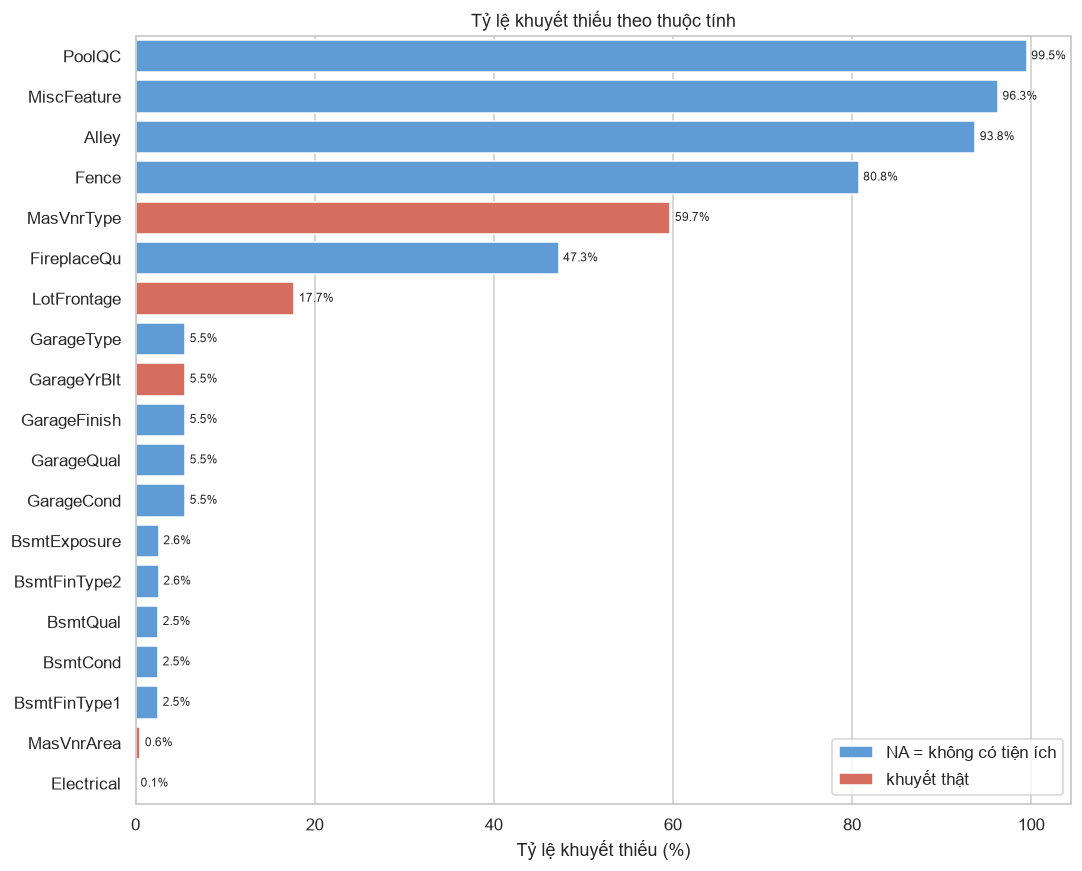

In [20]:
palette = {"NA = không có tiện ích": "#4C9BE8", "khuyết thật": "#E8604C"}

fig, ax = plt.subplots(figsize=(10, 0.32 * len(summary) + 2))
sns.barplot(x="pct_missing", y=summary.index, hue="loai", data=summary,
            palette=palette, dodge=False, ax=ax)
for i, v in enumerate(summary["pct_missing"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
ax.set(xlabel="Tỷ lệ khuyết thiếu (%)", ylabel="", title="Tỷ lệ khuyết thiếu theo thuộc tính")
ax.legend(title="")
plt.tight_layout()
save("01_missing_bar.png")
plt.show()

### 1.3. Heatmap vị trí khuyết thiếu

Ô tối = giá trị bị khuyết. Dòng được sắp theo số cột khuyết nên các khối `Garage*`, `Bsmt*` hiện thành mảng liền nhau.

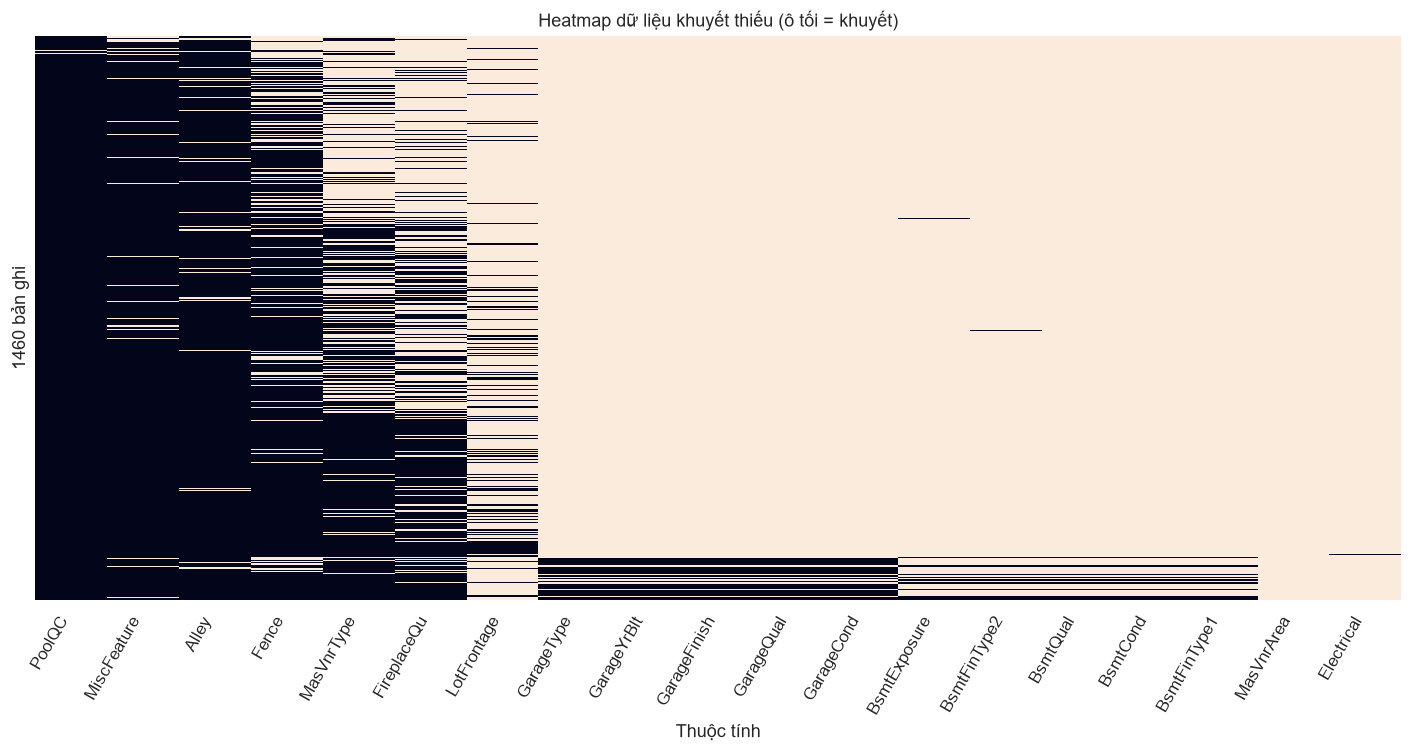

In [21]:
mask = df[summary.index].isnull()                       # cột đã sắp theo % khuyết giảm dần
mask = mask.loc[mask.sum(axis=1).sort_values().index]   # dòng ít khuyết ở trên

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(mask, cbar=False, yticklabels=False, cmap="rocket_r", ax=ax)
ax.set(title="Heatmap dữ liệu khuyết thiếu (ô tối = khuyết)",
       xlabel="Thuộc tính", ylabel=f"{len(df)} bản ghi")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
save("02_missing_heatmap.png")
plt.show()

### 1.4. Tương quan giữa các cột khuyết thiếu

Giá trị gần 1 nghĩa là hai cột cùng khuyết trên cùng các dòng, tức cùng một nguyên nhân (ví dụ cùng là *không có gara*).

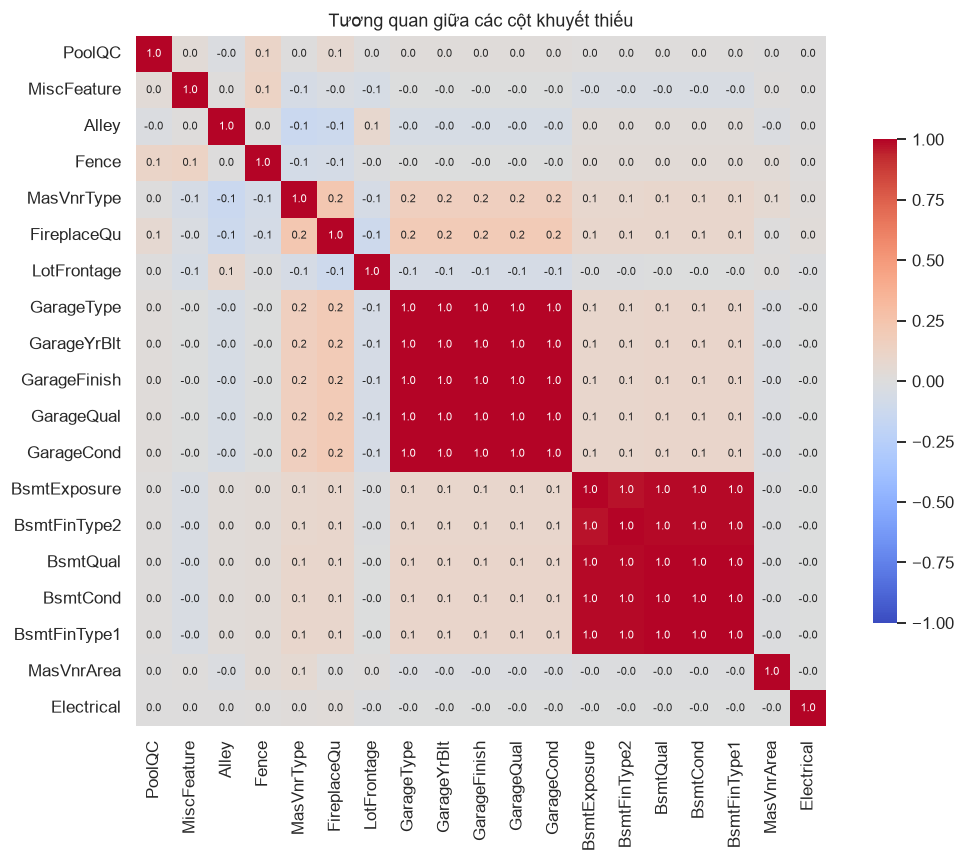

In [22]:
miss_corr = df[summary.index].isnull().astype(int).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(miss_corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True,
            annot=True, fmt=".1f", annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Tương quan giữa các cột khuyết thiếu")
plt.tight_layout()
save("03_missing_correlation.png")
plt.show()

### 1.5. Kiểm tra tính nhất quán của nhóm Garage

Nếu `GarageType` khuyết mà các cột Garage khác cũng khuyết/bằng 0 thì đúng là *không có gara*, không phải lỗi nhập liệu.

In [23]:
no_garage = df["GarageType"].isnull()
print("Số nhà không có gara (GarageType NA):", no_garage.sum())

for c in ["GarageYrBlt", "GarageFinish", "GarageQual", "GarageCond"]:
    print(f"{c:13s} khuyết cùng dòng:", df.loc[no_garage, c].isnull().sum())

print("GarageArea == 0 :", (df.loc[no_garage, "GarageArea"] == 0).sum())
print("GarageCars == 0 :", (df.loc[no_garage, "GarageCars"] == 0).sum())

Số nhà không có gara (GarageType NA): 81
GarageYrBlt   khuyết cùng dòng: 81
GarageFinish  khuyết cùng dòng: 81
GarageQual    khuyết cùng dòng: 81
GarageCond    khuyết cùng dòng: 81
GarageArea == 0 : 81
GarageCars == 0 : 81


## 2. Phát hiện ngoại lệ bằng scatter plot

### 2.1. `GrLivArea` vs `SalePrice`

Hai điểm có diện tích > 4000 sq ft nhưng giá thấp (sao đỏ) là ứng viên loại bỏ.

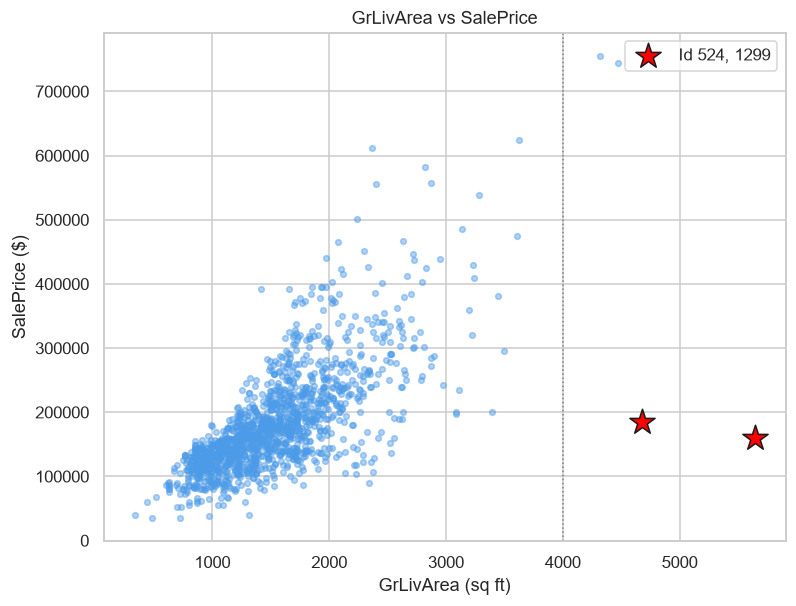

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["GrLivArea"], df["SalePrice"], s=14, alpha=0.45, color="#4C9BE8")

out_pts = df[df["Id"].isin(KNOWN_OUTLIER_IDS)]
ax.scatter(out_pts["GrLivArea"], out_pts["SalePrice"], marker="*", s=300,
           color="red", edgecolor="k", zorder=5, label="Id 524, 1299")
ax.axvline(4000, color="gray", ls=":", lw=1)

ax.set(xlabel="GrLivArea (sq ft)", ylabel="SalePrice ($)", title="GrLivArea vs SalePrice")
ax.legend()
save("04a_grlivarea_scatter.png")
plt.show()

### 2.2. Xem các điểm nghi vấn trong bảng

So sánh hai căn bị loại (524, 1299) với hai căn cũng rất lớn nhưng giá cao (692, 1183).

In [25]:
cols = ["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]
df.loc[df["Id"].isin(KNOWN_OUTLIER_IDS + LARGE_BUT_VALID_IDS), cols]

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
691,692,4316,755000,10,Normal
1182,1183,4476,745000,10,Abnorml
1298,1299,5642,160000,10,Partial


### 2.3. Hàm phụ: z-score của phần dư hồi quy

Đo mức độ một điểm *lạc khỏi xu hướng* tuyến tính `y ~ x`. Điểm có |z| lớn là nghi ngờ ngoại lệ.

In [26]:
def zscore_residual(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    resid = y - (slope * x + intercept)
    return (resid - resid.mean()) / resid.std(), slope, intercept

### 2.4. Hàm phụ: vẽ một cặp thuộc tính

Điểm cam là |z| > ngưỡng, sao đỏ là Id 524/1299, đường đứt là hồi quy. Gắn nhãn Id cho 4 điểm lạc xa nhất.

In [27]:
def plot_pair(ax, x, y):
    sub = df[["Id", x, y]].dropna().reset_index(drop=True)
    z, slope, intercept = zscore_residual(sub[x].values, sub[y].values)
    flag = np.abs(z) > Z_THRESH
    known = sub["Id"].isin(KNOWN_OUTLIER_IDS)

    ax.scatter(sub.loc[~flag, x], sub.loc[~flag, y], s=14, alpha=0.45, color="#4C9BE8")
    ax.scatter(sub.loc[flag, x], sub.loc[flag, y], s=34, color="#F29B34", edgecolor="k", linewidth=0.4)
    ax.scatter(sub.loc[known, x], sub.loc[known, y], marker="*", s=240, color="red", edgecolor="k", zorder=5)

    xs = np.linspace(sub[x].min(), sub[x].max(), 100)
    ax.plot(xs, slope * xs + intercept, "--", color="gray", lw=1.2)

    top = np.argsort(-np.abs(z))[:4]
    for i in set(top) | set(sub.index[known]):
        ax.annotate(str(int(sub.loc[i, "Id"])), (sub.loc[i, x], sub.loc[i, y]),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set(xlabel=x, ylabel=y, title=f"{x} vs {y}  ({flag.sum()} điểm |z|>{Z_THRESH:g})")

    return {"x": x, "n": len(sub), "pearson_r": round(sub[x].corr(sub[y]), 3),
            "n_flagged": int(flag.sum()), "top_Ids": sub.loc[top, "Id"].astype(int).tolist()}

### 2.5. Lưới scatter plot cho nhiều cặp thuộc tính

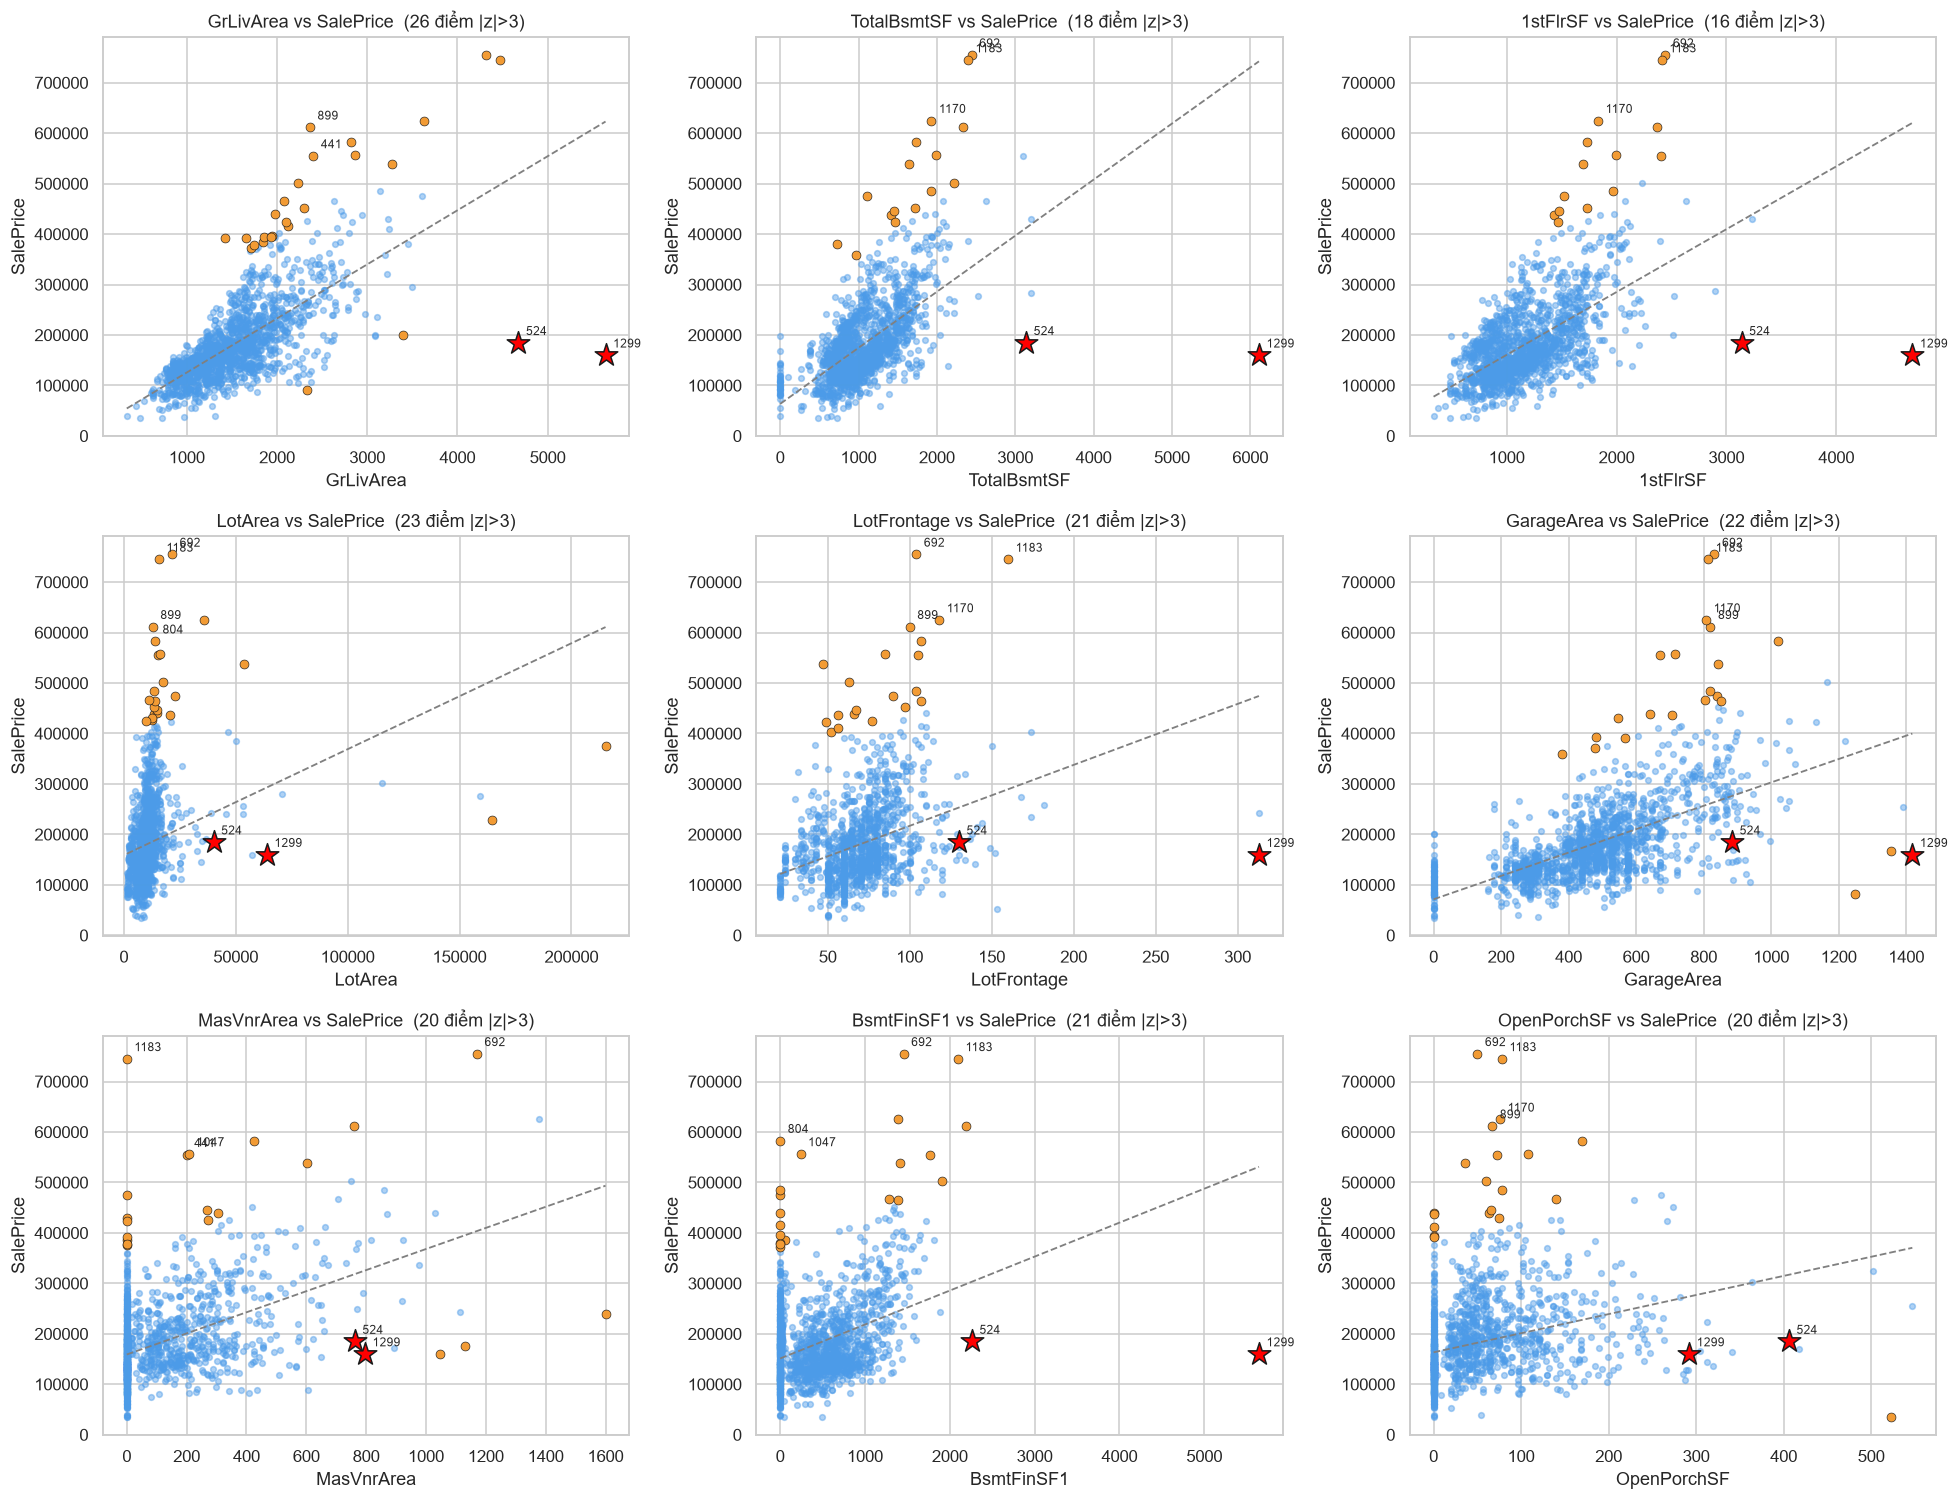

In [28]:
n_cols = 3
n_rows = int(np.ceil(len(SCATTER_PAIRS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.6 * n_rows))

report = [plot_pair(ax, x, y) for ax, (x, y) in zip(axes.ravel(), SCATTER_PAIRS)]

plt.tight_layout()
save("04_scatter_grid.png")
plt.show()

### 2.6. Bảng tổng hợp theo từng cặp

`top_Ids` là các Id lạc xa xu hướng nhất. Đối chiếu với biểu đồ trước khi quyết định loại, vì nhà đặc biệt (lô đất rất lớn...) có thể là điểm hợp lệ.

In [29]:
pd.DataFrame(report)

,x,n,pearson_r,n_flagged,top_Ids
0,GrLivArea,1460,0.709,26,"[1299, 899, 524, 441]"
1,TotalBsmtSF,1460,0.614,18,"[1299, 692, 1183, 1170]"
2,1stFlrSF,1460,0.606,16,"[1299, 692, 1183, 1170]"
3,LotArea,1460,0.264,23,"[1183, 692, 899, 804]"
4,LotFrontage,1201,0.352,21,"[692, 1183, 899, 1170]"
5,GarageArea,1460,0.623,22,"[692, 1183, 1170, 899]"
6,MasVnrArea,1452,0.477,20,"[1183, 441, 1047, 692]"
7,BsmtFinSF1,1460,0.386,21,"[692, 1183, 804, 1047]"
8,OpenPorchSF,1460,0.316,20,"[692, 1183, 1170, 899]"


### 2.7. Trước/sau khi loại Id 524 và 1299 — tính số liệu

In [30]:
clean = df[~df["Id"].isin(KNOWN_OUTLIER_IDS)]

s0, i0 = np.polyfit(df["GrLivArea"], df["SalePrice"], 1)
s1, i1 = np.polyfit(clean["GrLivArea"], clean["SalePrice"], 1)
r0 = df["GrLivArea"].corr(df["SalePrice"])
r1 = clean["GrLivArea"].corr(clean["SalePrice"])

print(f"Hệ số góc: trước = {s0:.2f} $/sqft | sau = {s1:.2f} $/sqft")
print(f"Pearson r: trước = {r0:.4f} | sau = {r1:.4f}")

Hệ số góc: trước = 107.13 $/sqft | sau = 115.04 $/sqft
Pearson r: trước = 0.7086 | sau = 0.7350


### 2.8. Trước/sau khi loại — biểu đồ so sánh

Màu điểm theo `OverallQual`. Hai căn bị loại có chất lượng cao nhưng giá thấp bất thường.

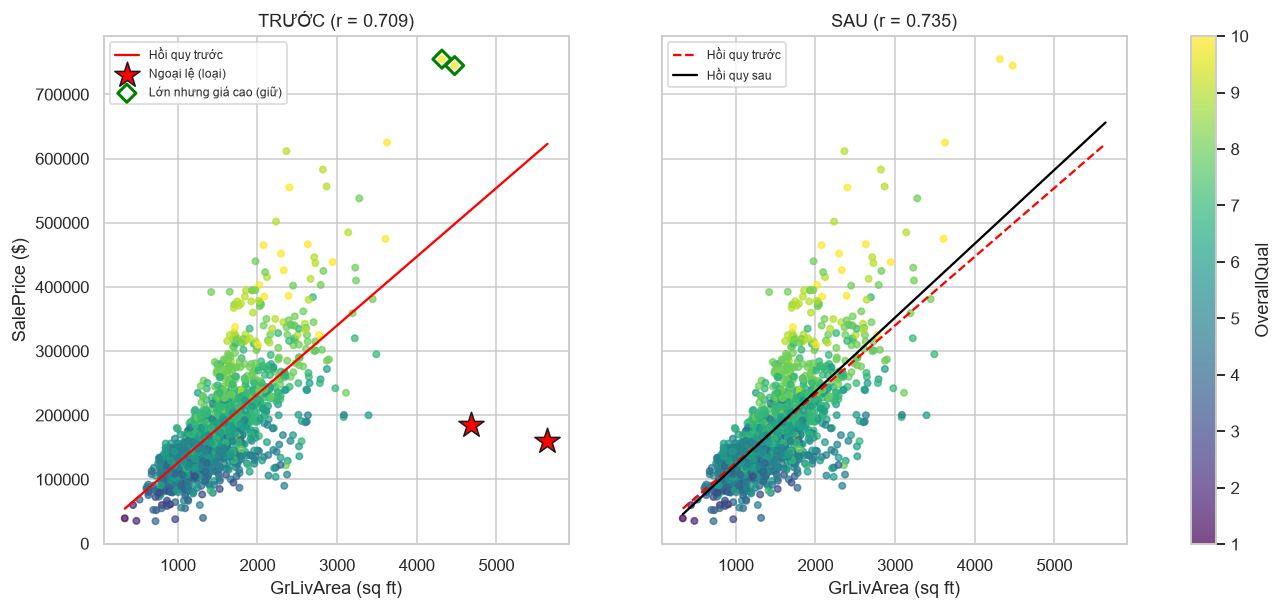

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
xs = np.linspace(df["GrLivArea"].min(), df["GrLivArea"].max(), 100)

for ax, data, title in zip(axes, [df, clean], [f"TRƯỚC (r = {r0:.3f})", f"SAU (r = {r1:.3f})"]):
    sc = ax.scatter(data["GrLivArea"], data["SalePrice"], c=data["OverallQual"],
                    cmap="viridis", s=18, alpha=0.7)
    ax.set(title=title, xlabel="GrLivArea (sq ft)")

axes[0].set_ylabel("SalePrice ($)")
axes[0].plot(xs, s0 * xs + i0, color="red", label="Hồi quy trước")
axes[1].plot(xs, s0 * xs + i0, "--", color="red", label="Hồi quy trước")
axes[1].plot(xs, s1 * xs + i1, color="black", label="Hồi quy sau")

ok_pts = df[df["Id"].isin(LARGE_BUT_VALID_IDS)]
axes[0].scatter(out_pts["GrLivArea"], out_pts["SalePrice"], marker="*", s=300,
                color="red", edgecolor="k", zorder=5, label="Ngoại lệ (loại)")
axes[0].scatter(ok_pts["GrLivArea"], ok_pts["SalePrice"], marker="D", s=70,
                facecolor="none", edgecolor="green", linewidth=2, zorder=5, label="Lớn nhưng giá cao (giữ)")

for ax in axes:
    ax.legend(fontsize=8, loc="upper left")
fig.colorbar(sc, ax=list(axes), label="OverallQual")
save("05_grlivarea_before_after.png")
plt.show()

## 3. Boxplot & quy tắc IQR

### 3.1. Đếm số outlier theo IQR cho mọi cột số

Outlier là giá trị ngoài khoảng `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

In [32]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["Id", "SalePrice"])

q1, q3 = df[num_cols].quantile(0.25), df[num_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()

iqr_tbl = pd.DataFrame({
    "n_outlier": n_out,
    "pct": (n_out / df[num_cols].count() * 100).round(2),
    "lower": lower.round(1),
    "upper": upper.round(1),
    "skew": df[num_cols].skew().round(2),
})
iqr_tbl = iqr_tbl[iqr > 0].sort_values("n_outlier", ascending=False)
iqr_tbl.head(15)

,n_outlier,pct,lower,upper,skew
OverallCond,125,8.56,3.5,7.5,0.69
MSSubClass,103,7.05,-55.0,145.0,1.41
MasVnrArea,96,6.61,-249.0,415.0,2.67
LotFrontage,88,7.33,27.5,111.5,2.16
OpenPorchSF,77,5.27,-102.0,170.0,2.36
LotArea,69,4.73,1481.5,17673.5,12.21
TotalBsmtSF,61,4.18,42.0,2052.0,1.52
BedroomAbvGr,35,2.40,0.5,4.5,0.21
WoodDeckSF,32,2.19,-252.0,420.0,1.54
GrLivArea,31,2.12,158.6,2747.6,1.37


### 3.2. Boxplot của 8 cột có nhiều outlier nhất

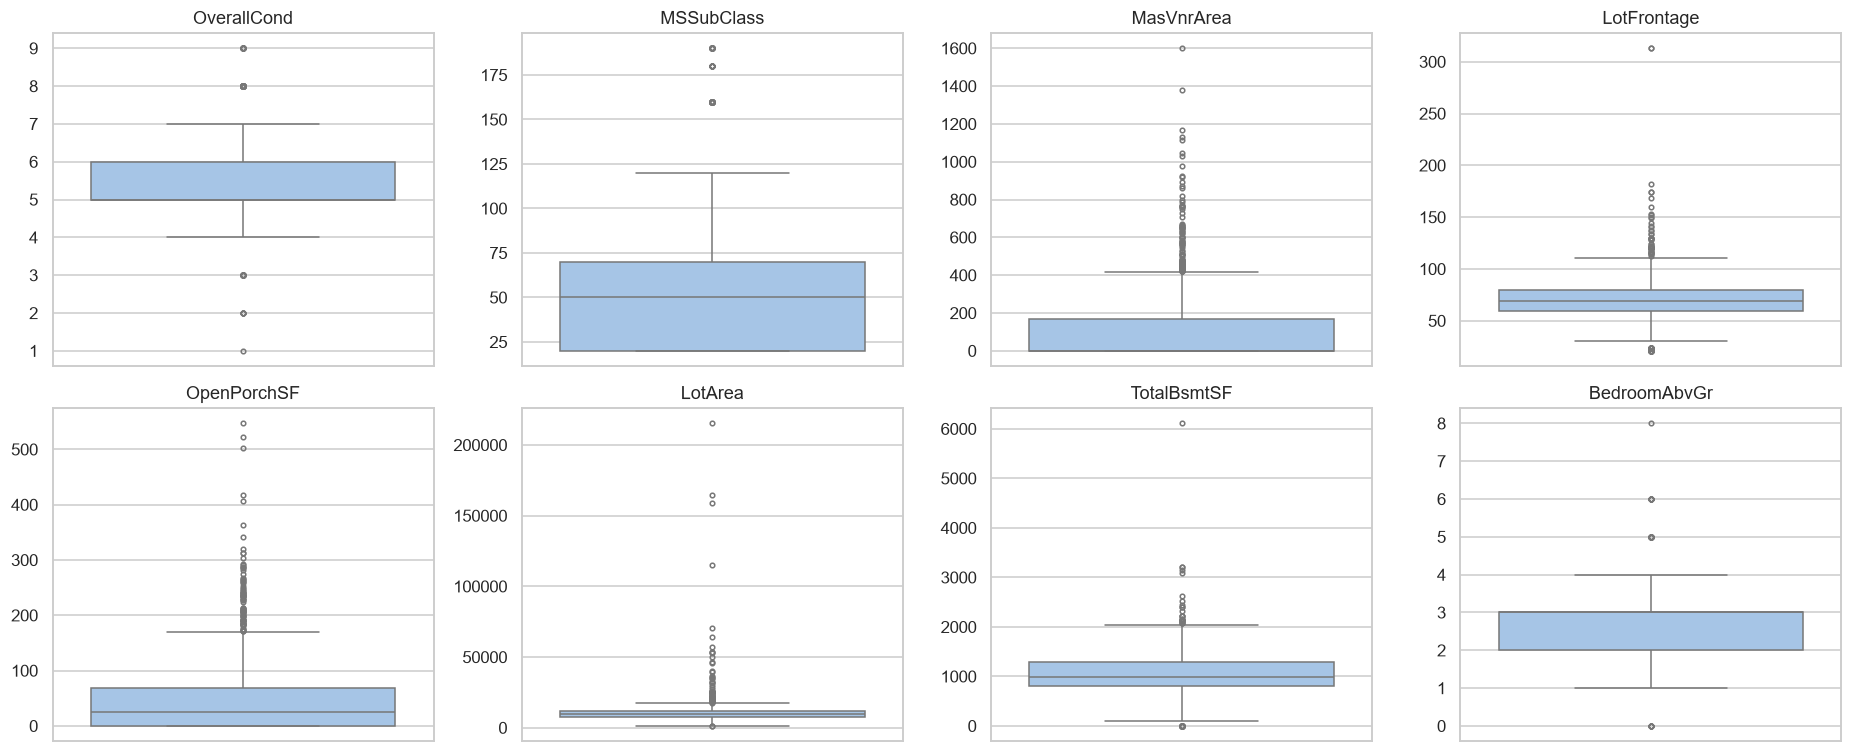

In [33]:
top_cols = iqr_tbl.head(8).index

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, c in zip(axes.ravel(), top_cols):
    sns.boxplot(y=df[c], ax=ax, color="#9CC5F0", fliersize=3)
    ax.set(title=c, ylabel="")
plt.tight_layout()
save("06_boxplots.png")
plt.show()

### 3.3. `SalePrice` theo nhóm

Giúp thấy điểm bất thường *trong từng nhóm* (theo chất lượng, số chỗ đỗ xe, khu vực).

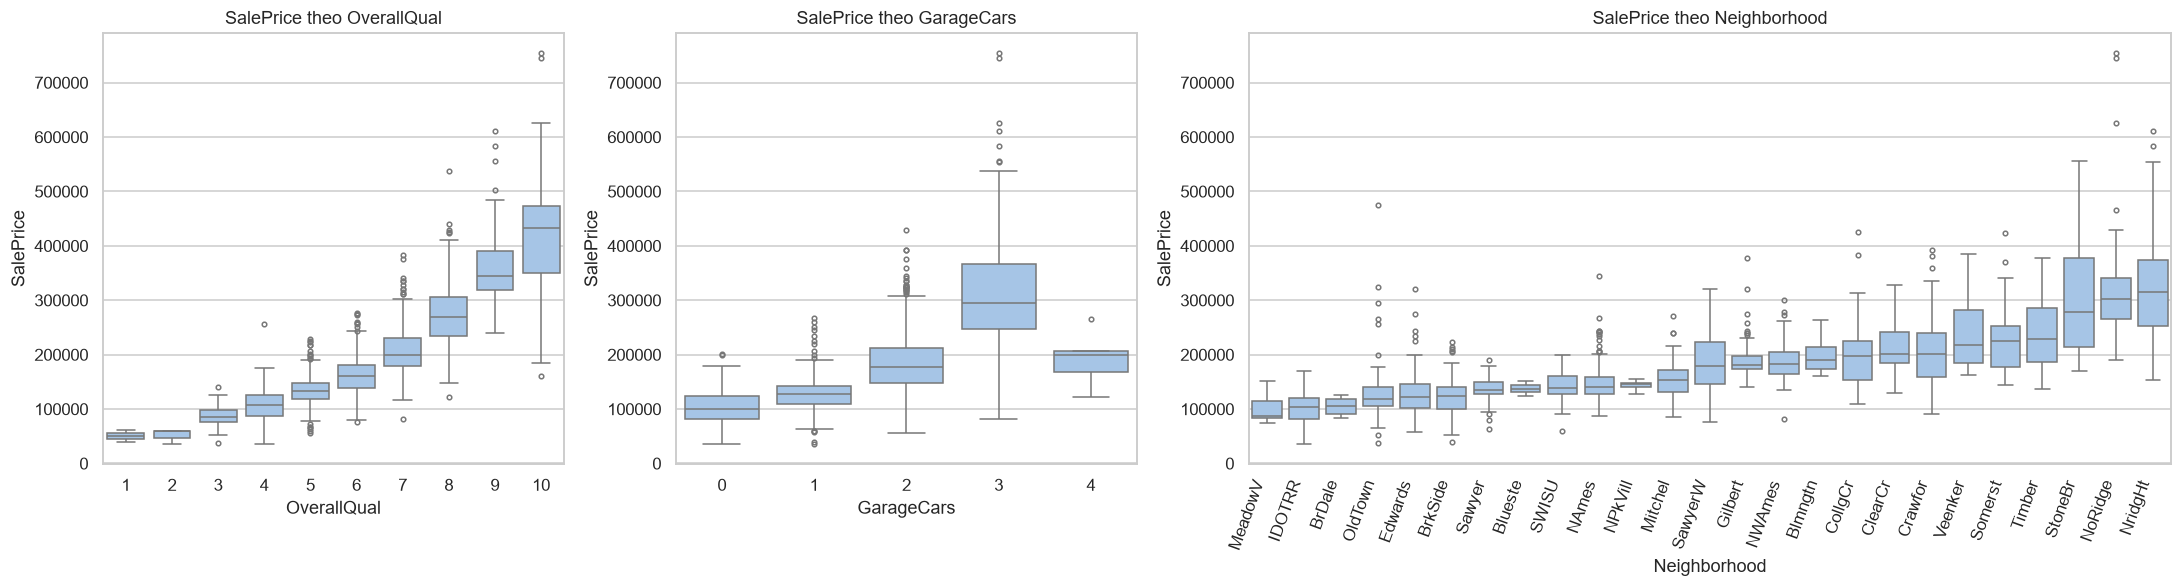

In [34]:
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), gridspec_kw={"width_ratios": [1, 1, 2]})
sns.boxplot(x="OverallQual", y="SalePrice", data=df, ax=axes[0], color="#9CC5F0", fliersize=3)
sns.boxplot(x="GarageCars", y="SalePrice", data=df, ax=axes[1], color="#9CC5F0", fliersize=3)
sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=order, ax=axes[2], color="#9CC5F0", fliersize=3)

plt.setp(axes[2].get_xticklabels(), rotation=70, ha="right")
for ax, t in zip(axes, ["theo OverallQual", "theo GarageCars", "theo Neighborhood"]):
    ax.set_title(f"SalePrice {t}")
plt.tight_layout()
save("07_boxplot_by_group.png")
plt.show()

## 4. Phân phối biến mục tiêu `SalePrice`

### 4.1. Histogram trước/sau `log1p`

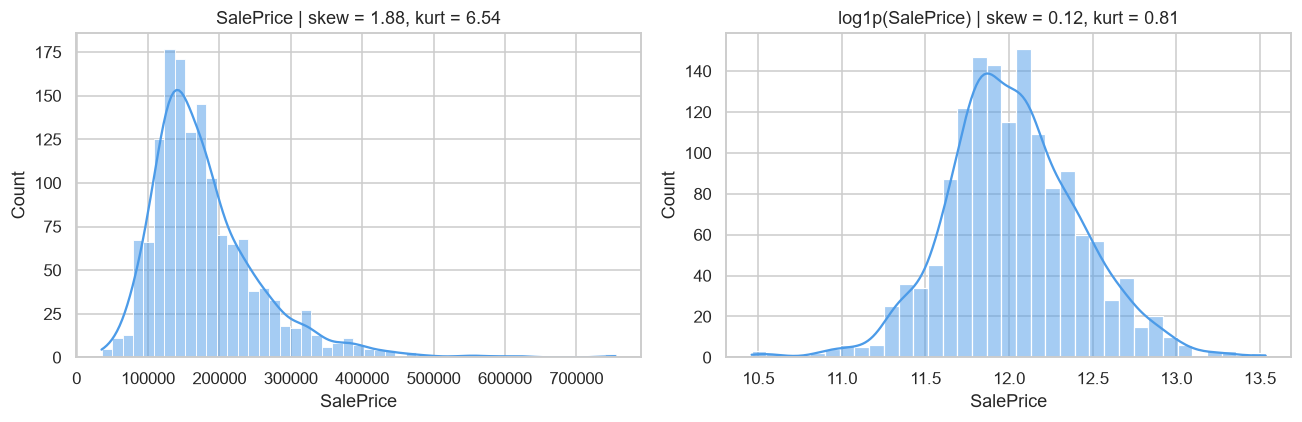

In [35]:
y = df["SalePrice"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, name in zip(axes, [y, np.log1p(y)], ["SalePrice", "log1p(SalePrice)"]):
    sns.histplot(data, kde=True, ax=ax, color="#4C9BE8")
    ax.set_title(f"{name} | skew = {data.skew():.2f}, kurt = {data.kurt():.2f}")
plt.tight_layout()
save("08_target_hist.png")
plt.show()

### 4.2. Q-Q plot trước/sau `log1p`

Các điểm nằm sát đường thẳng nghĩa là phân phối gần chuẩn.

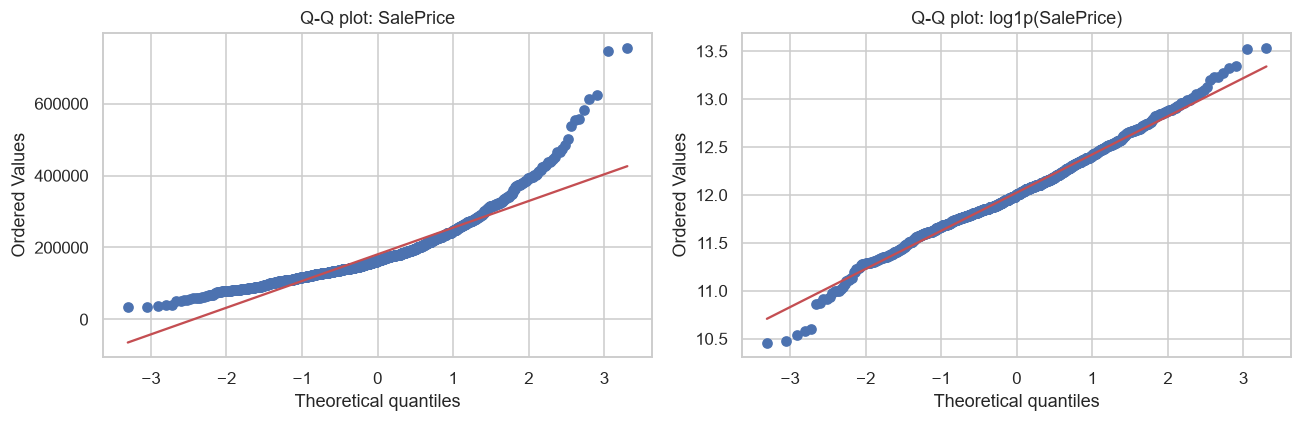

In [36]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, name in zip(axes, [y, np.log1p(y)], ["SalePrice", "log1p(SalePrice)"]):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {name}")
plt.tight_layout()
save("08_target_qq.png")
plt.show()

### 4.3. Số căn nhà giá siêu cao (> $500,000)

Dùng để cân nhắc có cần capping/clipping hay không khi đã dùng `log1p`.

In [37]:
n_hi = (y > 500_000).sum()
print(f"Số căn > $500,000: {n_hi} ({n_hi / len(y) * 100:.2f}%)")
print(f"Độ lệch (skew): {y.skew():.2f} -> {np.log1p(y).skew():.2f} sau log1p")

Số căn > $500,000: 9 (0.62%)
Độ lệch (skew): 1.88 -> 0.12 sau log1p


### 4.4. Pairplot các biến tương quan mạnh nhất với `SalePrice`

['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


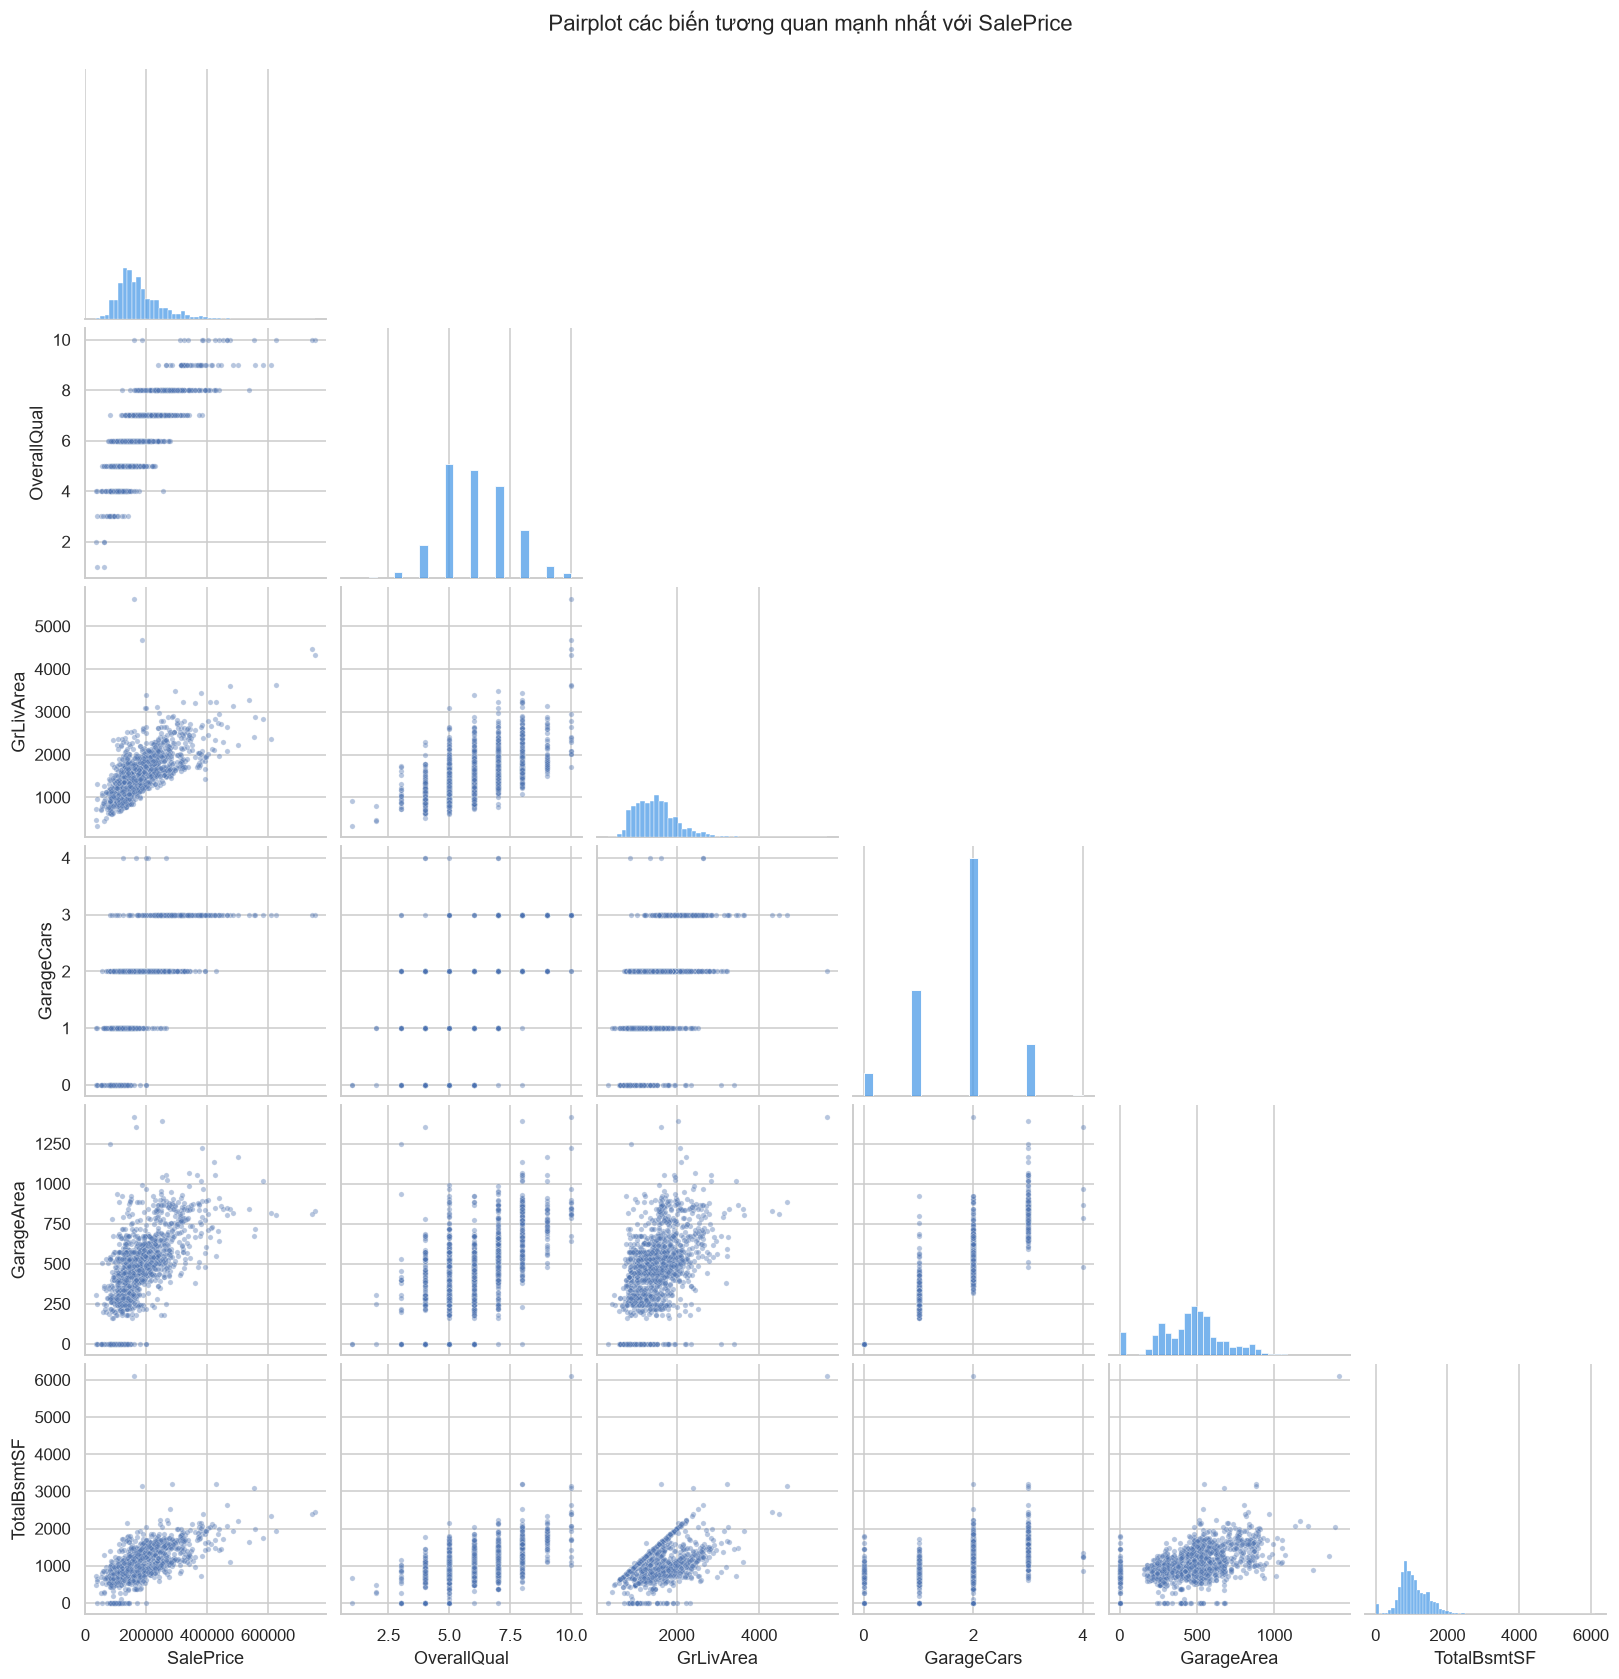

In [38]:
corr_target = df.select_dtypes(include=np.number).corr()["SalePrice"].abs().sort_values(ascending=False)
top_corr = corr_target.index[:6].tolist()
print(top_corr)

g = sns.pairplot(df[top_corr], corner=True, plot_kws={"alpha": 0.4, "s": 12},
                 diag_kws={"color": "#4C9BE8"})
g.figure.suptitle("Pairplot các biến tương quan mạnh nhất với SalePrice", y=1.02)
save("09_pairplot_top_corr.png")
plt.show()